In [2]:
import numpy as np
import matplotlib.pyplot as pp
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde


In [3]:
lap = np.load('lap_results.npz')
map_ = np.load('map_results.npz')

In [4]:
# Unpack
lap_delta_samples  = lap['delta_samples']
lap_omega0_samples = lap['omega0_samples']
lap_x_pred         = lap['x_pred']
t_obs              = lap['t_obs']
y_obs              = lap['y_obs']

map_delta_samples  = map_['delta_samples']
map_omega0_samples = map_['omega0_samples']
map_x_pred         = map_['x_pred']
theta_map          = map_['theta_map']

# True values
delta_true  = 0.0750
omega0_true = 0.3162

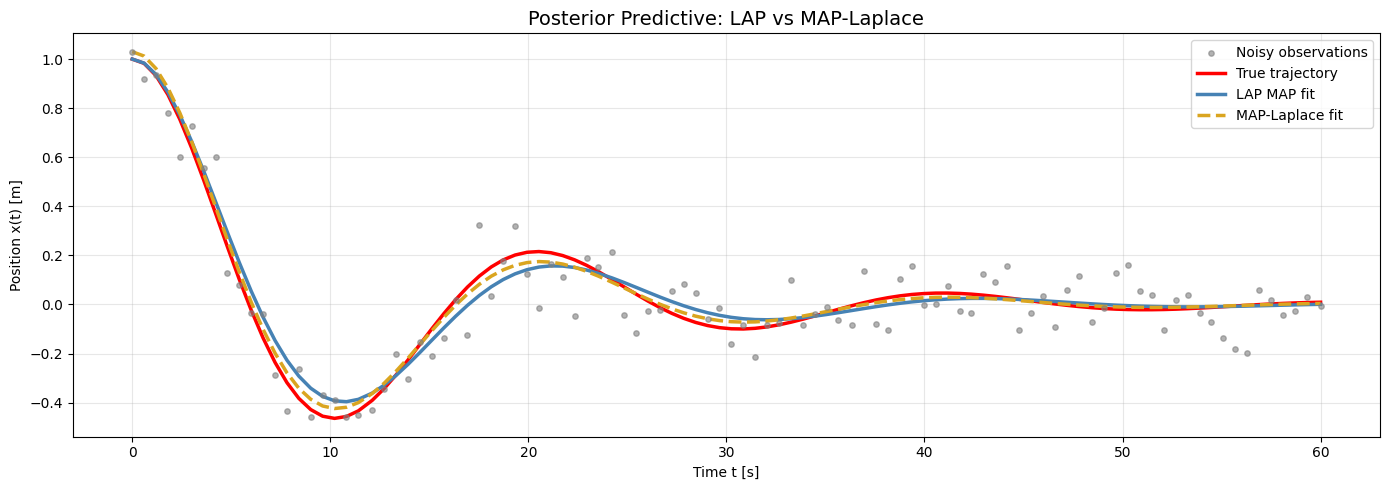

Saved: poster_predictive.png


In [6]:
# posterior predictive plot
# True trajectory
def mass_damper(delta, omega0, t):
    omega = np.sqrt(omega0**2 - delta**2)
    phi   = np.arctan(-delta/omega)
    A     = 1/(2*np.cos(phi))
    return np.exp(-delta*t) * 2*A * np.cos(phi + omega*t)

x_true = mass_damper(delta_true, omega0_true, t_obs)

fig, ax = pp.subplots(figsize=(14, 5))

ax.scatter(t_obs, y_obs, s=15, color='grey', alpha=0.6, 
           zorder=3, label='Noisy observations')
ax.plot(t_obs, x_true, color='red', 
        lw=2.5, linestyle='-', label='True trajectory')
ax.plot(t_obs, lap_x_pred, color='steelblue', 
        lw=2.5, label='LAP MAP fit')
ax.plot(t_obs, map_x_pred, color='goldenrod', 
        lw=2.5, linestyle='--', label='MAP-Laplace fit')

ax.set_xlabel('Time t [s]')
ax.set_ylabel('Position x(t) [m]')
ax.set_title('Posterior Predictive: LAP vs MAP-Laplace', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

pp.tight_layout()
pp.savefig('poster_predictive.png', dpi=200, bbox_inches='tight')
pp.show()
print("Saved: poster_predictive.png")

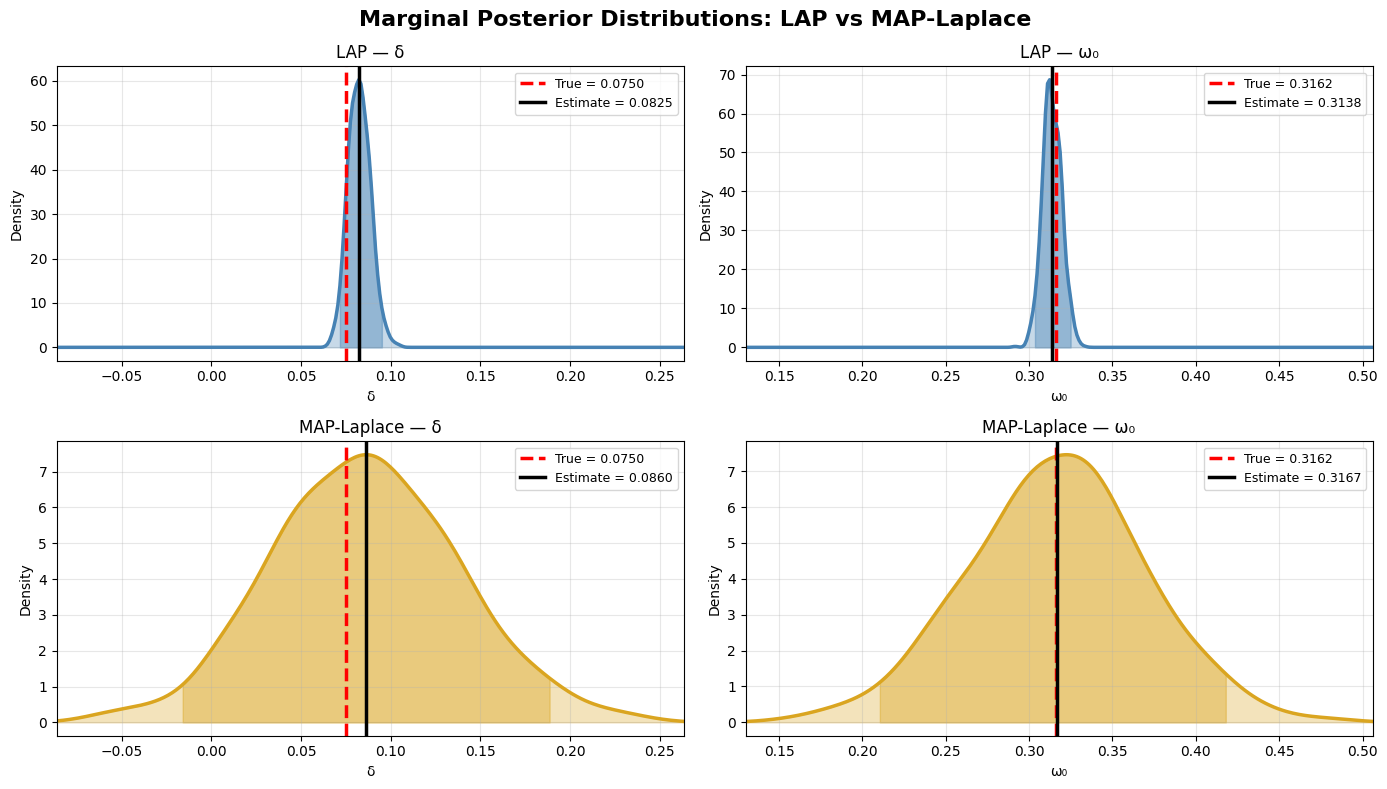

In [13]:
# Compute shared x limits per parameter
delta_xmin  = min(lap_delta_samples.min(),  map_delta_samples.min())  - 0.02
delta_xmax  = max(lap_delta_samples.max(),  map_delta_samples.max())  + 0.02
omega0_xmin = min(lap_omega0_samples.min(), map_omega0_samples.min()) - 0.02
omega0_xmax = max(lap_omega0_samples.max(), map_omega0_samples.max()) + 0.02

def plot_marginal(ax, samples, true_val, est_val, label, color, title, xmin, xmax):
    kde = gaussian_kde(samples, bw_method=0.3)
    xs  = np.linspace(xmin, xmax, 300)
    ys  = kde(xs)
    ax.plot(xs, ys, color=color, lw=2.5)
    ax.fill_between(xs, ys, alpha=0.3, color=color)
    ci      = np.percentile(samples, [2.5, 97.5])
    ci_mask = (xs >= ci[0]) & (xs <= ci[1])
    ax.fill_between(xs[ci_mask], ys[ci_mask], alpha=0.4, color=color)
    ax.axvline(true_val, color='red',   lw=2.5, linestyle='--',
               label=f'True = {true_val:.4f}')
    ax.axvline(est_val,  color='black', lw=2.5, linestyle='-',
               label=f'Estimate = {est_val:.4f}')
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig, axes = pp.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Marginal Posterior Distributions: LAP vs MAP-Laplace',
             fontsize=16, fontweight='bold')

plot_marginal(axes[0,0], lap_delta_samples,  delta_true,
              np.mean(lap_delta_samples),  'δ',  'steelblue',
              'LAP — δ',  delta_xmin,  delta_xmax)

plot_marginal(axes[0,1], lap_omega0_samples, omega0_true,
              np.mean(lap_omega0_samples), 'ω₀', 'steelblue',
              'LAP — ω₀', omega0_xmin, omega0_xmax)

plot_marginal(axes[1,0], map_delta_samples,  delta_true,
              theta_map[0], 'δ',  'goldenrod',
              'MAP-Laplace — δ',  delta_xmin,  delta_xmax)

plot_marginal(axes[1,1], map_omega0_samples, omega0_true,
              theta_map[1], 'ω₀', 'goldenrod',
              'MAP-Laplace — ω₀', omega0_xmin, omega0_xmax)

pp.tight_layout()
pp.savefig('poster_marginals.png', dpi=200, bbox_inches='tight')
pp.show()

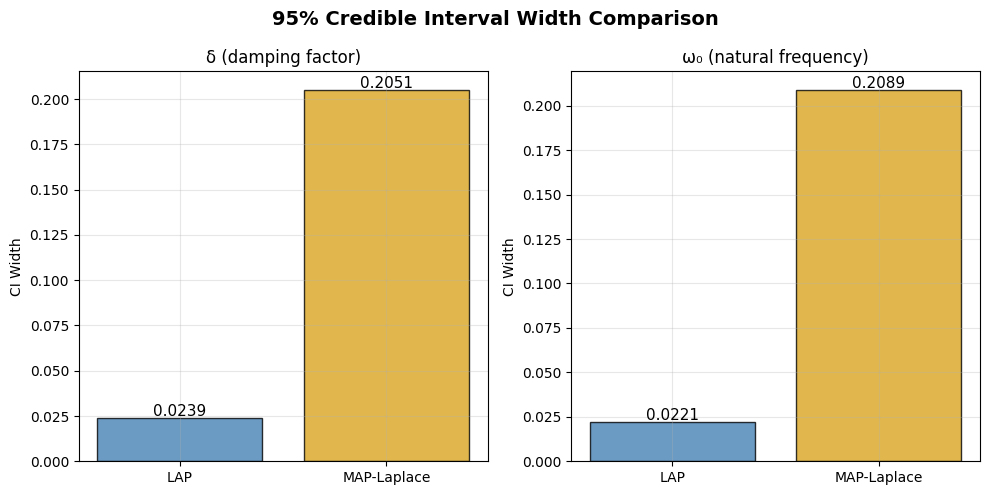

Saved: poster_ci_comparison.png


In [8]:
fig, axes = pp.subplots(1, 2, figsize=(10, 5))
fig.suptitle('95% Credible Interval Width Comparison', 
             fontsize=14, fontweight='bold')

methods = ['LAP', 'MAP-Laplace']
colors  = ['steelblue', 'goldenrod']

lap_delta_ci   = np.percentile(lap_delta_samples,  [2.5, 97.5])
lap_omega0_ci  = np.percentile(lap_omega0_samples, [2.5, 97.5])
map_delta_ci   = np.percentile(map_delta_samples,  [2.5, 97.5])
map_omega0_ci  = np.percentile(map_omega0_samples, [2.5, 97.5])

delta_widths  = [lap_delta_ci[1]  - lap_delta_ci[0],
                 map_delta_ci[1]  - map_delta_ci[0]]
omega0_widths = [lap_omega0_ci[1] - lap_omega0_ci[0],
                 map_omega0_ci[1] - map_omega0_ci[0]]

for ax, widths, param in zip(axes,
                              [delta_widths, omega0_widths],
                              ['δ (damping factor)', 'ω₀ (natural frequency)']):
    bars = ax.bar(methods, widths, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('CI Width')
    ax.set_title(param)
    for bar, w in zip(bars, widths):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{w:.4f}', ha='center', fontsize=11)
    ax.grid(True, alpha=0.3)

pp.tight_layout()
pp.savefig('poster_ci_comparison.png', dpi=200, bbox_inches='tight')
pp.show()
print("Saved: poster_ci_comparison.png")

In [12]:
import pandas as pd

lap_delta_ci   = np.percentile(lap_delta_samples,  [2.5, 97.5])
lap_omega0_ci  = np.percentile(lap_omega0_samples, [2.5, 97.5])
map_delta_ci   = np.percentile(map_delta_samples,  [2.5, 97.5])
map_omega0_ci  = np.percentile(map_omega0_samples, [2.5, 97.5])

results = {
    '': [
        'True value',
        'Point estimate',
        '95% CI',
        'CI width',
        'True in CI',
        'Runtime'
    ],
    'LAP — δ': [
        f'{delta_true:.4f}',
        f'{np.mean(lap_delta_samples):.4f}',
        f'[{lap_delta_ci[0]:.4f}, {lap_delta_ci[1]:.4f}]',
        f'{lap_delta_ci[1] - lap_delta_ci[0]:.4f}',
        '✓' if lap_delta_ci[0] <= delta_true <= lap_delta_ci[1] else '✗',
        '~12 min'
    ],
    'LAP — ω₀': [
        f'{omega0_true:.4f}',
        f'{np.mean(lap_omega0_samples):.4f}',
        f'[{lap_omega0_ci[0]:.4f}, {lap_omega0_ci[1]:.4f}]',
        f'{lap_omega0_ci[1] - lap_omega0_ci[0]:.4f}',
        '✓' if lap_omega0_ci[0] <= omega0_true <= lap_omega0_ci[1] else '✗',
        ''
    ],
    'MAP-Laplace — δ': [
        f'{delta_true:.4f}',
        f'{theta_map[0]:.4f}',
        f'[{map_delta_ci[0]:.4f}, {map_delta_ci[1]:.4f}]',
        f'{map_delta_ci[1] - map_delta_ci[0]:.4f}',
        '✓' if map_delta_ci[0] <= delta_true <= map_delta_ci[1] else '✗',
        '~5 sec'
    ],
    'MAP-Laplace — ω₀': [
        f'{omega0_true:.4f}',
        f'{theta_map[1]:.4f}',
        f'[{map_omega0_ci[0]:.4f}, {map_omega0_ci[1]:.4f}]',
        f'{map_omega0_ci[1] - map_omega0_ci[0]:.4f}',
        '✓' if map_omega0_ci[0] <= omega0_true <= map_omega0_ci[1] else '✗',
        ''
    ],
}

df = pd.DataFrame(results)
print(df.to_string(index=False))

                        LAP — δ         LAP — ω₀   MAP-Laplace — δ MAP-Laplace — ω₀
    True value           0.0750           0.3162            0.0750           0.3162
Point estimate           0.0825           0.3138            0.0860           0.3167
        95% CI [0.0713, 0.0952] [0.3029, 0.3250] [-0.0162, 0.1889] [0.2100, 0.4188]
      CI width           0.0239           0.0221            0.2051           0.2089
    True in CI                ✓                ✓                 ✓                ✓
       Runtime          ~12 min                             ~5 sec                 
